In [19]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
ds_radio = xr.open_dataset('radiometer.nc')
ds_radio

<xarray.Dataset> Size: 233MB
Dimensions:      (time: 1296072)
Coordinates:
  * time         (time) datetime64[ns] 10MB 2025-01-01 ... 2025-12-31T23:59:51
Data variables: (12/41)
    base_time    (time) datetime64[ns] 10MB ...
    time_offset  (time) datetime64[ns] 10MB ...
    qc_time      (time) int32 5MB ...
    tknd         (time) float32 5MB ...
    qc_tknd      (time) int32 5MB ...
    tkxc         (time) float32 5MB ...
    ...           ...
    tnd_nom31    (time) float32 5MB ...
    tc23         (time) float32 5MB ...
    tc31         (time) float32 5MB ...
    lat          (time) float32 5MB ...
    lon          (time) float32 5MB ...
    alt          (time) float32 5MB ...
Attributes: (12/55)
    command_line:                       mwr_ingest -s sgp -f C1
    process_version:                    ingest-mwr-2.3-0.el7
    ingest_software:                    ingest-mwr-2.3-0.el7
    dod_version:                        mwrlos-b1-2.3
    site_id:                            sgp
    facility_id:                        C1: Lamont, Oklahoma
    ...                                 ...
    datastream:                         sgpmwrlosC1.b1
    history:                            created by user dsmgr on machine prod...
    _file_dates:                        ['20250101', '20250101', '20250102', ...
    _file_times:                        ['000000', '000040', '000020', '00000...
    _datastream:                        sgpmwrlosC1.b1
    _arm_standards_flag:                1

In [3]:
ds_mfrs = xr.open_dataset('mfrs.nc')
ds_mfrs

<xarray.Dataset> Size: 25MB
Dimensions:                              (time: 1573879)
Coordinates:
  * time                                 (time) datetime64[ns] 13MB 2025-01-0...
Data variables:
    direct_normal_narrowband_filter6     (time) float32 6MB ...
    qc_direct_normal_narrowband_filter6  (time) int32 6MB ...
Attributes: (12/38)
    command_line:                mfrsr7nch_ingest -s sgp -f C1
    Conventions:                 ARM-1.2
    process_version:             ingest-mfrsr7nch-1.8-0.el7
    dod_version:                 mfrsr7nch-b1-1.1
    input_source:                /data/collection/sgp/sgpmfrsr7nchC1.00/MFRSR...
    site_id:                     sgp
    ...                          ...
    doi:                         10.5439/1429369
    history:                     created by user dsmgr on machine prod-proc3....
    _file_dates:                 ['20250101', '20250102', '20250103', '202501...
    _file_times:                 ['070000', '070000', '070000', '070000', '07...
    _datastream:                 sgpmfrsr7nchC1.b1
    _arm_standards_flag:         1

In [11]:
qc_vap_idx = np.where(ds_radio['qc_vap'].values == 0)
qc_direct_idx = np.where(ds_mfrs['qc_direct_normal_narrowband_filter6'].values == 0)

vap_time = ds_radio['time'].values[qc_vap_idx]
direct_time = ds_mfrs['time'].values[qc_direct_idx]

vap_values = ds_radio['vap'].values[qc_vap_idx]
direct_values = ds_mfrs['direct_normal_narrowband_filter6'].values[qc_direct_idx]

# create time mask
mask1 = np.isin(vap_time, direct_time)
mask2 = np.isin(direct_time, vap_time)

In [12]:
vap_time[mask1]

array(['2025-01-01T07:00:20.000000000', '2025-01-01T07:01:00.000000000',
       '2025-01-01T07:19:00.000000000', ...,
       '2025-12-31T23:24:40.000000000', '2025-12-31T23:38:00.000000000',
       '2025-12-31T23:52:00.000000000'],
      shape=(574881,), dtype='datetime64[ns]')

In [13]:
direct_time[mask2]

array(['2025-01-01T07:00:20.000000000', '2025-01-01T07:01:00.000000000',
       '2025-01-01T07:19:00.000000000', ...,
       '2025-12-31T23:24:40.000000000', '2025-12-31T23:38:00.000000000',
       '2025-12-31T23:52:00.000000000'],
      shape=(574881,), dtype='datetime64[ns]')

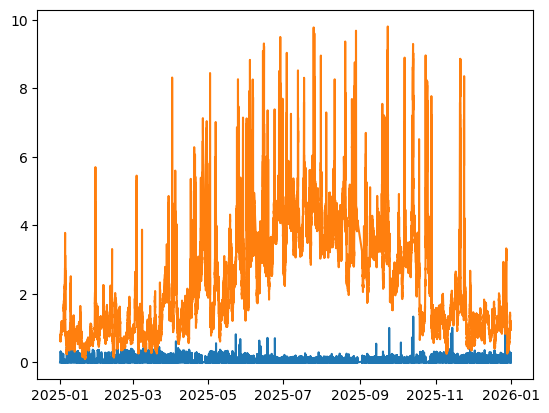

In [14]:
plt.plot(direct_time[mask2], direct_values[mask2])
plt.plot(vap_time[mask1], vap_values[mask1])

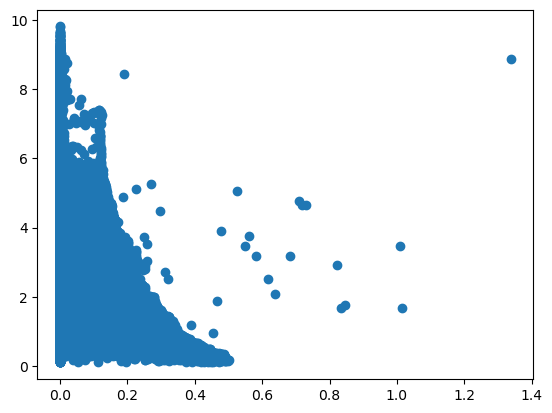

In [15]:
plt.scatter(direct_values[mask2], vap_values[mask1])

In [25]:
# split the datasets into training, validation, and testing
x_data = direct_values[mask2] 
y_data = vap_values[mask1] / 10


In [34]:
x_train = x_data[:int(x_data.shape[0]*0.8)]
x_val = x_data[int(x_data.shape[0]*0.8):int(x_data.shape[0]*0.9)]
x_test = x_data[int(x_data.shape[0]*0.9):]

y_train = y_data[:int(x_data.shape[0]*0.8)]
y_val = y_data[int(x_data.shape[0]*0.8):int(x_data.shape[0]*0.9)]
y_test = y_data[int(x_data.shape[0]*0.9):]

print(x_train.shape[0], y_train.shape[0])

459904 459904


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Setup DataLoaders
# (Assuming your data are already PyTorch Tensors: X_train, y_train, etc.)
# Replace these with your actual tensor names
BATCH_SIZE = 64

# 1. Convert your data to PyTorch tensors
# Force features to be floats (needed for neural net weights) 
# and labels to be long integers (needed for CrossEntropyLoss)
X_train_tensor = torch.tensor(x_train, dtype=torch.float32).reshape(-1, 1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(x_val, dtype=torch.float32).reshape(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(x_test, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Shuffle training data to prevent the model from learning order dependencies
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. Initialize Model, Loss, and Optimizer
# (Using the 10 -> 32 -> 2 architecture from before)
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

criterion = nn.MSELoss()  # Built-in softmax + negative log-likelihood
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training & Validation Loop
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    # --- TRAINING PHASE ---
    model.train()  # Sets the model to training mode
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()           # Clear old gradients from previous step
        outputs = model(batch_X)        # Forward pass
        loss = criterion(outputs, batch_y) # Calculate loss
        loss.backward()                 # Backward pass (compute gradients)
        optimizer.step()                # Update network weights
        
        running_train_loss += loss.item() * batch_X.size(0)
    
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    
    # --- VALIDATION PHASE ---
    model.eval()  # Sets the model to evaluation mode (turns off dropout/batchnorm)
    running_val_loss = 0.0
    
    with torch.no_grad():  # Disables gradient calculation to save memory and speed up
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item() * batch_X.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

# 4. Final Testing Phase
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        absolute_errors = torch.abs(predictions - batch_y)
        total_absolute_error += absolute_errors.sum().item()

average_mae = total_absolute_error / len(test_loader.dataset)
print(f"\nFinal Test Mean Absolute Error (MAE): {average_mae:.4f}")

Epoch 1/10 | Train Loss: 0.0205 | Val Loss: 0.0179
